In [184]:
import torch
import pandas as pd
import numpy as np
import sklearn.metrics as metric
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [185]:
from data_load import scaled_data, raw_data, result, data_info

In [186]:
raw_data.head()

,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


In [187]:
raw_data.describe()

,idx,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
count,11939.000000,11939,1.193900e+04,1.193900e+04,11939.000000,11939.000000,11939.000000,11939.000000
mean,732.280761,2020-03-29 10:49:44.571572,7.000000e-01,7.000000e-01,2.787925,14.711208,2.704223,71.724123
min,1.000000,2020-03-24 00:00:00,7.000000e-01,7.000000e-01,1.740000,14.520000,2.464000,70.000000
25%,332.000000,2020-03-26 00:00:00,7.000000e-01,7.000000e-01,2.310000,14.610000,2.699000,71.000000
50%,664.000000,2020-03-30 00:00:00,7.000000e-01,7.000000e-01,2.340000,14.730000,2.702000,72.000000
75%,1081.000000,2020-04-02 00:00:00,7.000000e-01,7.000000e-01,2.370000,14.750000,2.706000,72.000000
max,2000.000000,2020-04-07 00:00:00,7.000000e-01,7.000000e-01,10.540000,15.070000,2.861000,73.000000
std,481.996313,NaN,1.110270e-16,1.110270e-16,1.455966,0.099000,0.024700,0.632049


In [188]:
labels_to_drop = ['idx', 'Machine_Name', 'Item No', 'working time', 'Thickness 1(mm)', 'Thickness 2(mm)']

df = raw_data.drop(columns=labels_to_drop, errors='ignore')

df['Energy'] = df['weld current(kA)'] * df['weld Voltage(v)'] * df['weld time(ms)']
df['Resistance'] = df['weld Voltage(v)'] / df['weld current(kA)']
df['Force-Current Dynamics'] = df['weld current(kA)'] / df['weld force(bar)']
df['Power to Force Ratio'] = df['weld Voltage(v)'] * df['weld current(kA)'] / df['weld force(bar)']

split_index = 8470

df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print(f"Size of train dataset: {df_train.shape}")
print(f"Size of test dataset: {df_test.shape}")

df.corr()

Size of train dataset: (8470, 8)
Size of test dataset: (3469, 8)


,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Energy,Resistance,Force-Current Dynamics,Power to Force Ratio
weld force(bar),1.000000,0.411675,0.133876,-0.005557,0.265580,-0.145538,-0.982329,-0.983688
weld current(kA),0.411675,1.000000,0.129596,-0.020933,0.519101,-0.524082,-0.382536,-0.381570
weld Voltage(v),0.133876,0.129596,1.000000,0.010169,0.680115,0.776538,-0.207480,-0.188520
weld time(ms),-0.005557,-0.020933,0.010169,1.000000,0.587309,0.021984,0.003027,0.003148
Energy,0.265580,0.519101,0.680115,0.587309,1.000000,0.254268,-0.299174,-0.287001
Resistance,-0.145538,-0.524082,0.776538,0.021984,0.254268,1.000000,0.063587,0.079262
Force-Current Dynamics,-0.982329,-0.382536,-0.207480,0.003027,-0.299174,0.063587,1.000000,0.999754
Power to Force Ratio,-0.983688,-0.381570,-0.188520,0.003148,-0.287001,0.079262,0.999754,1.000000


In [189]:
scaler = RobustScaler()

train_scaled = np.clip(scaler.fit_transform(df_train), -10, 10)
test_scaled = np.clip(scaler.transform(df_test), -10, 10)

df_train_scaled = pd.DataFrame(train_scaled, columns=df_train.columns, index=df_train.index)
df_test_scaled = pd.DataFrame(test_scaled, columns=df_test.columns, index=df_test.index)

print(df_train_scaled.head())

   weld force(bar)  weld current(kA)  weld Voltage(v)  weld time(ms)  \
0        -0.166667         -1.142857        -0.142857            0.0   
1         0.333333         -1.142857        -0.142857            0.0   
2         0.500000         -1.357143         0.142857           -1.0   
3         0.500000         -1.357143         0.142857            0.0   
4         0.333333         -1.214286         0.285714            0.0   

     Energy  Resistance  Force-Current Dynamics  Power to Force Ratio  
0 -0.528620    0.909066               -0.141852             -0.159082  
1 -0.528620    0.909066               -0.482452             -0.497380  
2 -1.557875    1.177016               -0.648307             -0.642781  
3 -0.618063    1.177016               -0.648307             -0.642781  
4 -0.499919    1.080831               -0.500608             -0.486250  


In [190]:
input_dim = df_train_scaled.shape[1]

X_train_tensor = torch.FloatTensor(df_train_scaled.values)
X_test_tensor = torch.FloatTensor(df_test_scaled.values)

batch_size = 64
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [191]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim=8, dropout_rate=0.2):
        super(DenoisingAutoencoder, self).__init__()
        
        # 입력 데이터의 피처를 무작위로 0으로 마스킹 (Noise 주입 효과)
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # 인코더 (8 -> 16 -> 4 차원)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 4),
            nn.ReLU()
        )
        
        # 디코더 (4 -> 16 -> 8 차원)
        self.decoder = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        # 훈련 시에만 노이즈(Dropout)가 적용되며, 평가(eval) 시에는 원본이 그대로 통과됨
        x_noisy = self.dropout(x)
        latent = self.encoder(x_noisy)
        reconstructed = self.decoder(latent)
        return reconstructed

In [192]:
model = DenoisingAutoencoder(input_dim)

# 3. 손실 함수 및 옵티마이저 설정
# 복원 오차를 측정하기 위해 평균 제곱 오차(MSE)를 사용합니다.
criterion = nn.L1Loss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [193]:
epochs = 200
model.train() # 학습 모드 설정

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, _ in train_loader:
        # 옵티마이저 초기화
        optimizer.zero_grad()
        
        # 순전파 (Forward pass)
        outputs = model(batch_x)
        
        # 손실(복원 오차) 계산: 입력(batch_x)과 출력(outputs)의 차이
        loss = criterion(outputs, batch_x)
        
        # 역전파 (Backward pass) 및 가중치 업데이트
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    # 10 에포크마다 손실값 출력
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}')

Epoch [10/200], Loss: 0.2709
Epoch [20/200], Loss: 0.2326
Epoch [30/200], Loss: 0.1832
Epoch [40/200], Loss: 0.1672
Epoch [50/200], Loss: 0.1534
Epoch [60/200], Loss: 0.1490
Epoch [70/200], Loss: 0.1418
Epoch [80/200], Loss: 0.1375
Epoch [90/200], Loss: 0.1355
Epoch [100/200], Loss: 0.1322
Epoch [110/200], Loss: 0.1306
Epoch [120/200], Loss: 0.1258
Epoch [130/200], Loss: 0.1288
Epoch [140/200], Loss: 0.1309
Epoch [150/200], Loss: 0.1245
Epoch [160/200], Loss: 0.1275
Epoch [170/200], Loss: 0.1271
Epoch [180/200], Loss: 0.1268
Epoch [190/200], Loss: 0.1258
Epoch [200/200], Loss: 0.1265


In [194]:
model.eval() # 평가 모드 설정 (Dropout, BatchNorm 비활성화)

with torch.no_grad():
    train_reconstructed = model(X_train_tensor)
    train_mse_loss = torch.mean((X_train_tensor - train_reconstructed) ** 2, dim=1).numpy()
    
    # 테스트 데이터 복원 결과 및 오차 계산
    reconstructed = model(X_test_tensor)
    mse_loss = torch.mean((X_test_tensor - reconstructed) ** 2, dim=1).numpy()

# 결과 분석을 위해 테스트 데이터프레임에 복원 오차 파생변수 추가
df_test_with_loss = df_test_scaled.copy()
df_test_with_loss['Reconstruction_Error'] = mse_loss

# 임계값(Threshold)을 설정하여 이상치 판별
# 예: 훈련 데이터 오차의 분포를 분석하거나, 특정 상위 백분위수(예: 95%)를 임계값으로 지정
threshold = np.percentile(train_mse_loss, 98.5) 
df_test_with_loss['Is_Anomaly'] = df_test_with_loss['Reconstruction_Error'] > threshold

print(df_test_with_loss['Is_Anomaly'].value_counts())

Is_Anomaly
False    3427
True       42
Name: count, dtype: int64


In [195]:
feature_columns = df_test_scaled.columns.tolist()

error_df = pd.DataFrame(
    np.abs(X_test_tensor.numpy() - reconstructed.numpy()),
    columns=feature_columns,
    index=df_test_scaled.index
)

이상치 유형별 개수
Anomaly_Type
Anomaly Type 1    23
Anomaly Type 2    13
Anomaly Type 3     6
Name: count, dtype: int64


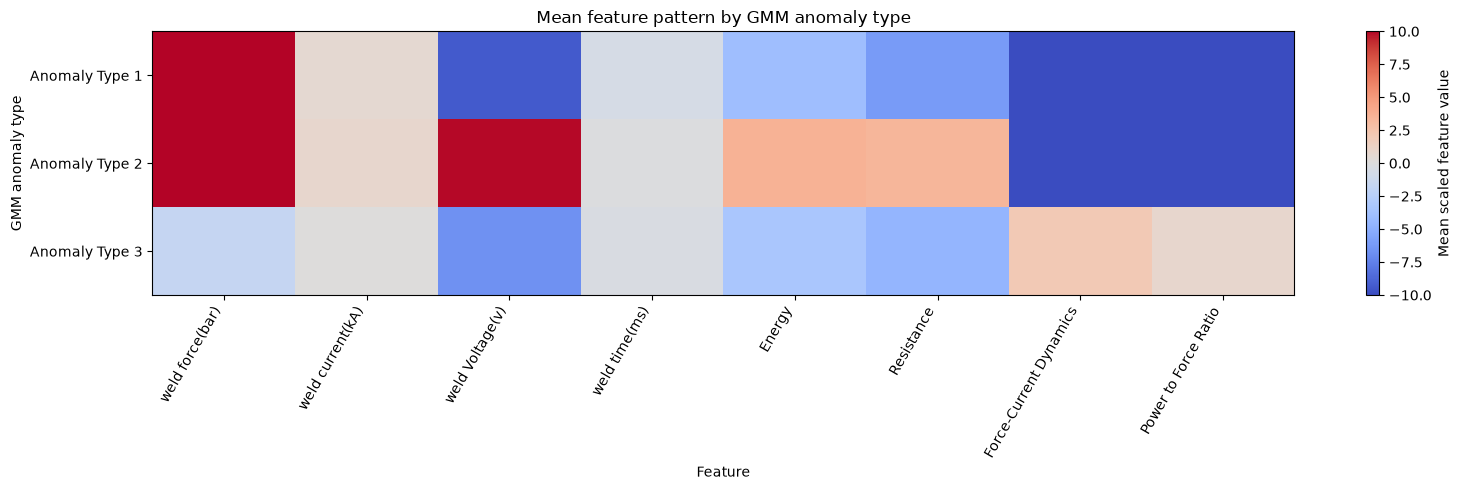

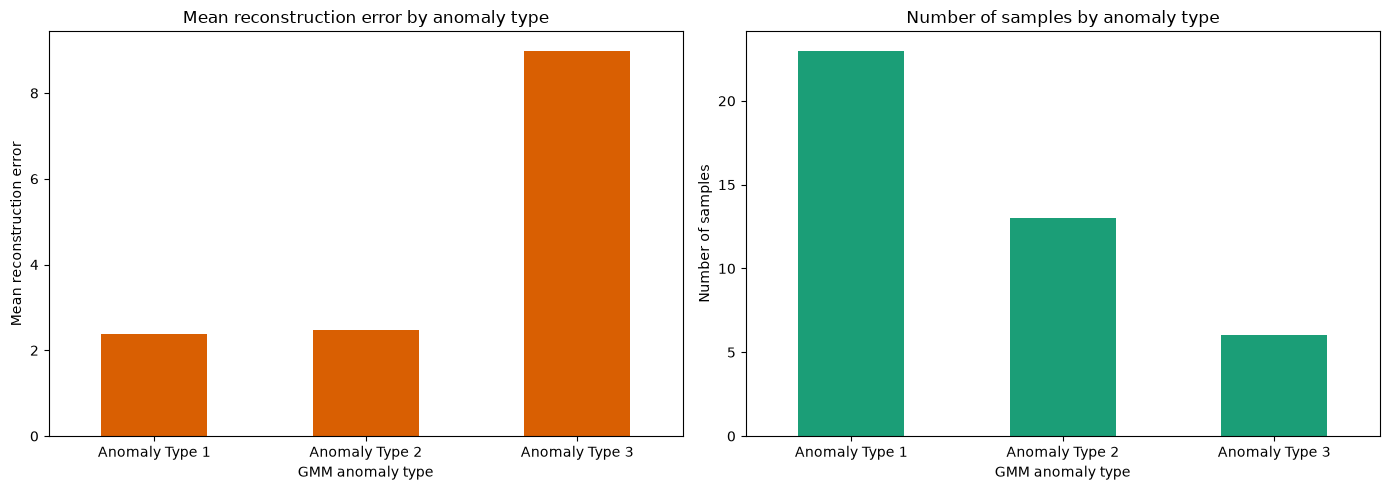

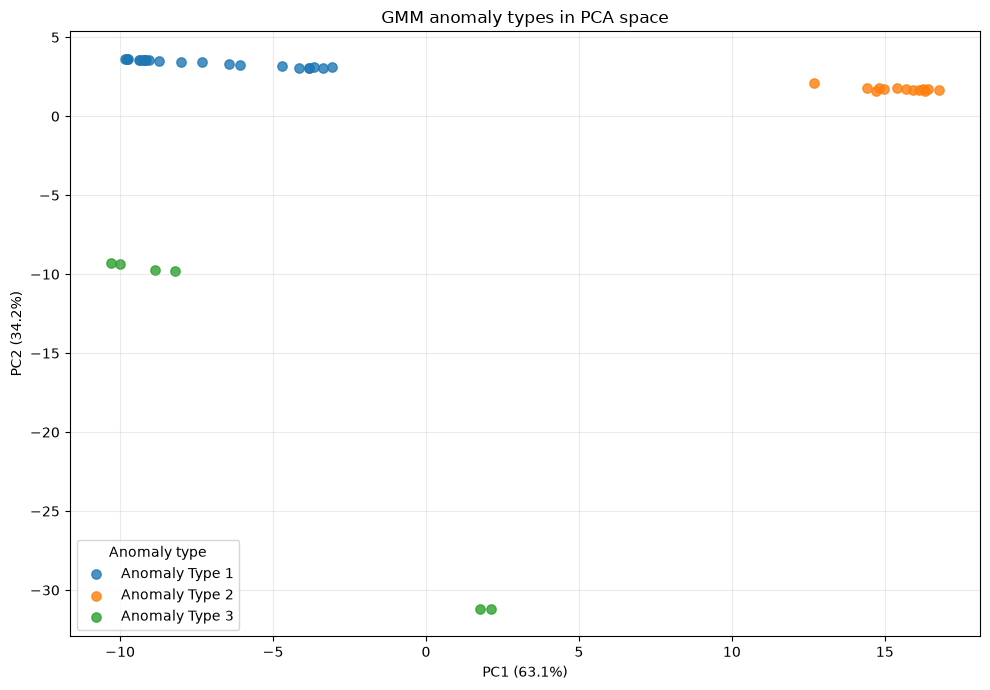

\nAnomaly Type 1 - reconstruction error가 큰 피처


,Mean absolute reconstruction error
Force-Current Dynamics,2.237344
Power to Force Ratio,2.174956
weld force(bar),2.005054
weld Voltage(v),1.495798
Resistance,1.145219


\nAnomaly Type 2 - reconstruction error가 큰 피처


,Mean absolute reconstruction error
Force-Current Dynamics,2.204082
Power to Force Ratio,2.190580
weld force(bar),1.765014
Energy,1.431533
weld Voltage(v),1.403721


\nAnomaly Type 3 - reconstruction error가 큰 피처


,Mean absolute reconstruction error
Power to Force Ratio,3.384647
weld Voltage(v),3.367015
weld force(bar),2.711563
Force-Current Dynamics,2.533882
Resistance,1.502571


In [196]:
# Autoencoder가 탐지한 이상치를 GMM으로 3가지 유형으로 분류
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

feature_columns = df_test_scaled.columns.tolist()
anomaly_mask = df_test_with_loss['Is_Anomaly'].astype(bool)
anomaly_data = df_test_scaled.loc[anomaly_mask, feature_columns].copy()
anomaly_errors = df_test_with_loss.loc[anomaly_mask, 'Reconstruction_Error'].copy()

if len(anomaly_data) < 3:
    raise ValueError(
        f'GMM 3개 그룹을 만들려면 이상치가 최소 3개 필요합니다. 현재 이상치는 {len(anomaly_data)}개입니다.'
    )

# GMM으로 이상치 피처 패턴을 3개 그룹으로 분류합니다.
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42,
    n_init=10
)
gmm_labels = gmm.fit_predict(anomaly_data)
anomaly_data['GMM_Label'] = gmm_labels
anomaly_data['Reconstruction_Error'] = anomaly_errors

# GMM label은 실행마다 의미가 바뀔 수 있으므로 평균 복원오차 순으로 이름을 고정합니다.
label_order = anomaly_data.groupby('GMM_Label')['Reconstruction_Error'].mean().sort_values().index
label_names = {
    label: f'Anomaly Type {rank + 1}'
    for rank, label in enumerate(label_order)
}
anomaly_data['Anomaly_Type'] = anomaly_data['GMM_Label'].map(label_names)

df_test_with_loss['Anomaly_Type'] = 'Normal'
df_test_with_loss.loc[anomaly_data.index, 'Anomaly_Type'] = anomaly_data['Anomaly_Type']

print('이상치 유형별 개수')
print(anomaly_data['Anomaly_Type'].value_counts().sort_index())

# 유형별 평균 피처값을 계산합니다.
type_feature_mean = anomaly_data.groupby('Anomaly_Type')[feature_columns].mean()
type_feature_mean = type_feature_mean.reindex(sorted(type_feature_mean.index))

# 1. 유형별 평균 피처 패턴 히트맵
plt.figure(figsize=(16, 5))
plt.imshow(type_feature_mean, aspect='auto', cmap='coolwarm')
plt.colorbar(label='Mean scaled feature value')
plt.xticks(range(len(feature_columns)), feature_columns, rotation=60, ha='right')
plt.yticks(range(len(type_feature_mean.index)), type_feature_mean.index)
plt.xlabel('Feature')
plt.ylabel('GMM anomaly type')
plt.title('Mean feature pattern by GMM anomaly type')
plt.tight_layout()
plt.show()

# 2. 유형별 평균 복원오차 비교
error_by_type = anomaly_data.groupby('Anomaly_Type')['Reconstruction_Error'].agg(
    ['mean', 'median', 'count']
).reindex(sorted(anomaly_data['Anomaly_Type'].unique()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
error_by_type['mean'].plot(kind='bar', ax=axes[0], color='#d95f02')
axes[0].set_title('Mean reconstruction error by anomaly type')
axes[0].set_xlabel('GMM anomaly type')
axes[0].set_ylabel('Mean reconstruction error')
axes[0].tick_params(axis='x', rotation=0)

error_by_type['count'].plot(kind='bar', ax=axes[1], color='#1b9e77')
axes[1].set_title('Number of samples by anomaly type')
axes[1].set_xlabel('GMM anomaly type')
axes[1].set_ylabel('Number of samples')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 3. PCA 2차원 공간에서 GMM 유형 분포 시각화
pca = PCA(n_components=2, random_state=42)
anomaly_pca = pca.fit_transform(anomaly_data[feature_columns])
pca_df = pd.DataFrame(anomaly_pca, columns=['PC1', 'PC2'], index=anomaly_data.index)
pca_df['Anomaly_Type'] = anomaly_data['Anomaly_Type']
pca_df['Reconstruction_Error'] = anomaly_data['Reconstruction_Error']

plt.figure(figsize=(10, 7))
for anomaly_type, group in pca_df.groupby('Anomaly_Type'):
    plt.scatter(
        group['PC1'],
        group['PC2'],
        s=45,
        alpha=0.8,
        label=anomaly_type
    )
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
plt.title('GMM anomaly types in PCA space')
plt.legend(title='Anomaly type')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 각 유형에서 복원오차가 큰 피처를 확인합니다.
for anomaly_type in sorted(anomaly_data['Anomaly_Type'].unique()):
    type_indices = anomaly_data.index[anomaly_data['Anomaly_Type'] == anomaly_type]
    mean_errors = error_df.loc[type_indices].mean().sort_values(ascending=False)
    print(f'\\n{anomaly_type} - reconstruction error가 큰 피처')
    display(mean_errors.head(5).to_frame('Mean absolute reconstruction error'))